In [ ]:
!pip install scikit-learn-extra
!pip install kneed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 33.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154554 sha256=bc77626653dfed96484221d54e11335a8b0d4742dd3e621b4f2bda602c95edc9
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from kneed import KneeLocator, DataGenerator
from sklearn.metrics import silhouette_samples, silhouette_score
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [ ]:
# load dataset
df = pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/CC%20GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.shape

(8950, 18)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [ ]:
df.corr(numeric_only=True)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303985,0.453238,0.140107,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119788,0.103464,0.003030,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295038,0.243537,-0.030327,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060755,0.085551,0.030073,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132616,0.183192,0.098838,-0.249773,-0.133372


In [ ]:
df_new = df.drop('CUST_ID', axis=1)
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df_new.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [ ]:
df_new['MINIMUM_PAYMENTS'].fillna(df_new['MINIMUM_PAYMENTS'].median(), inplace=True)
df_new['CREDIT_LIMIT'].fillna(df_new['CREDIT_LIMIT'].median(), inplace=True)

/tmp/ipykernel_895/3071234684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['MINIMUM_PAYMENTS'].fillna(df_new['MINIMUM_PAYMENTS'].median(), inplace=True)
/tmp/ipykernel_895/3071234684.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [ ]:
df_new.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [ ]:
X=df_new.astype(float).values
scaller=StandardScaler().fit(X)
X_new=scaller.transform(X)
X_new

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.0932934 ,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.32687479,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.33830497,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.3243581 ,
        -0.52555097, -4.12276757]])

In [ ]:
# metode elbow untuk menentukan jumlah k

inertia_list = []
for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters)
    kmeans_model.fit(X_new)
    inertia_list.append(kmeans_model.inertia_)
    print("For n_clusters = {}, inertia value is {}".format(num_clusters, kmeans_model.inertia_))

For n_clusters = 1, inertia value is 152150.0000000004
For n_clusters = 2, inertia value is 128953.36240712069
For n_clusters = 3, inertia value is 112651.5730532012
For n_clusters = 4, inertia value is 105337.38541525482
For n_clusters = 5, inertia value is 91795.80717173181
For n_clusters = 6, inertia value is 85766.75234752959
For n_clusters = 7, inertia value is 79746.50848529927
For n_clusters = 8, inertia value is 76067.83954193824
For n_clusters = 9, inertia value is 71608.91329756187
For n_clusters = 10, inertia value is 68218.96387891234


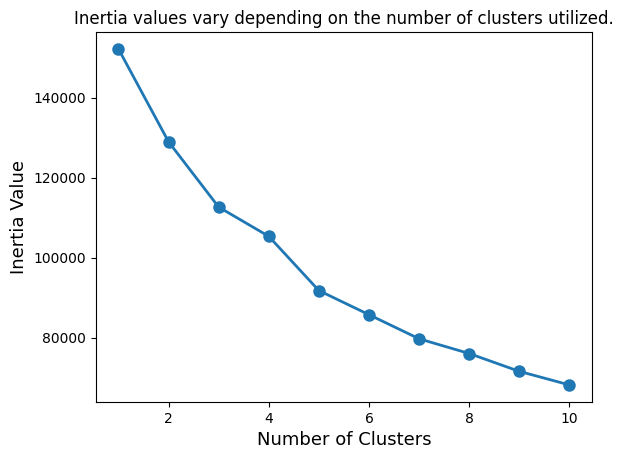

In [ ]:
# visualisasi metode elbow

plt.plot(range(1,11),inertia_list, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Inertia Value", size=13)
plt.title("Inertia values vary depending on the number of clusters utilized.")
plt.show()

In [ ]:
# menentukan titik optimal menggunakan kneed

kneedle = KneeLocator(range(1,11),inertia_list, S=1.0, curve='convex', direction='decreasing')
print(round(kneedle.knee, 3))
print(round(kneedle.elbow, 3))

5
5


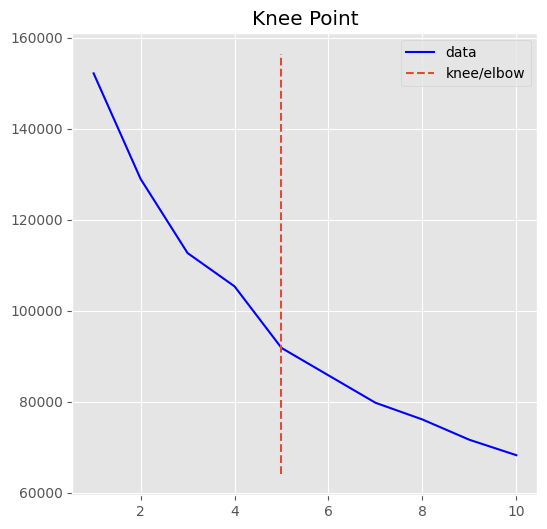

In [ ]:
# visualisasi titik optimal

plt.style.use('ggplot')
#kneedle.plot_knee_normalized()

kneedle.plot_knee()
# sampai di stage ini kita mendapatkan k=4 yg optimal
# reference
# https://www.kaggle.com/kevinarvai/knee-elbow-point-detection

In [ ]:
# mencari nilai k elbow method

inertia_list = []
for num_clusters in range(1, 11):
    kmedoids_model = KMedoids(n_clusters=num_clusters)
    kmedoids_model.fit(X_new)
    inertia_list.append(kmedoids_model.inertia_)
    print(f"The inertia of {num_clusters} clusters : {kmedoids_model.inertia_}")

The inertia of 1 clusters : 32074.48996380632
The inertia of 2 clusters : 28502.252083851865
The inertia of 3 clusters : 26690.45199631644
The inertia of 4 clusters : 25312.680447618714
The inertia of 5 clusters : 24410.14906458207
The inertia of 6 clusters : 25045.959805744402
The inertia of 7 clusters : 23865.264137617396
The inertia of 8 clusters : 23728.760889007306
The inertia of 9 clusters : 21901.105869527415
The inertia of 10 clusters : 23064.59573815541


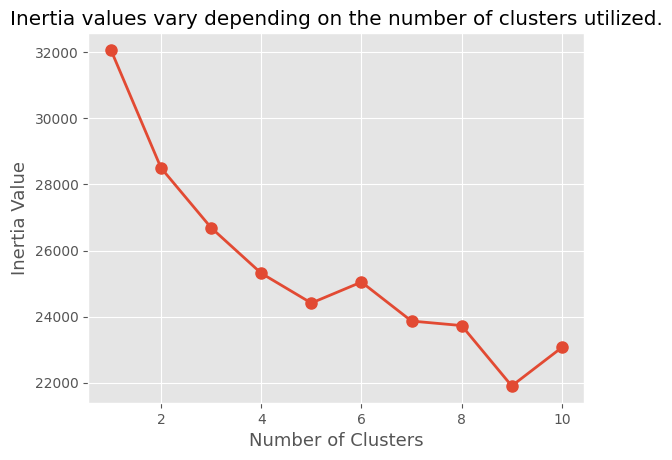

In [ ]:
# visualisasi elbow method

plt.plot(range(1,11),inertia_list, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Inertia Value", size=13)
plt.title("Inertia values vary depending on the number of clusters utilized.")
plt.show()

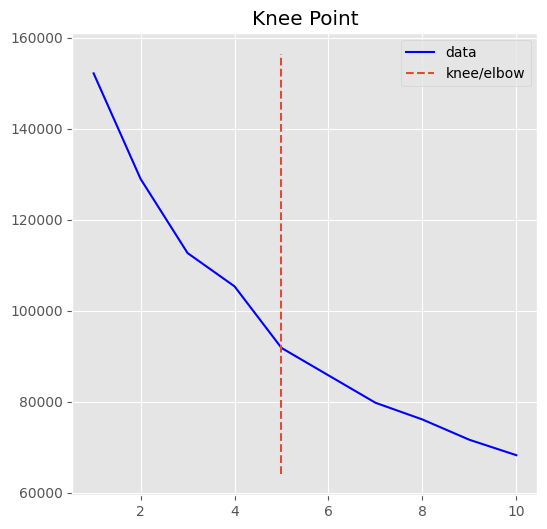

In [ ]:
# menentukan titik optimal dgn kneed

plt.style.use('ggplot')
#kneedle.plot_knee_normalized()
kneedle.plot_knee()

In [ ]:
# menentukan silhoutte score

sh_list = []
for num_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=num_clusters)
    cluster_labels = kmeans.fit_predict(X_new)

    score = silhouette_score(X_new, cluster_labels)
    sh_list.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(num_clusters, score))

For n_clusters = 2, silhouette score is 0.20949692655850133
For n_clusters = 3, silhouette score is 0.25056455881423495
For n_clusters = 4, silhouette score is 0.197508484089438
For n_clusters = 5, silhouette score is 0.19256596919095406
For n_clusters = 6, silhouette score is 0.2035255188966764
For n_clusters = 7, silhouette score is 0.19500311200245682
For n_clusters = 8, silhouette score is 0.2085147944571148
For n_clusters = 9, silhouette score is 0.20591271275866344
For n_clusters = 10, silhouette score is 0.19103038485803392


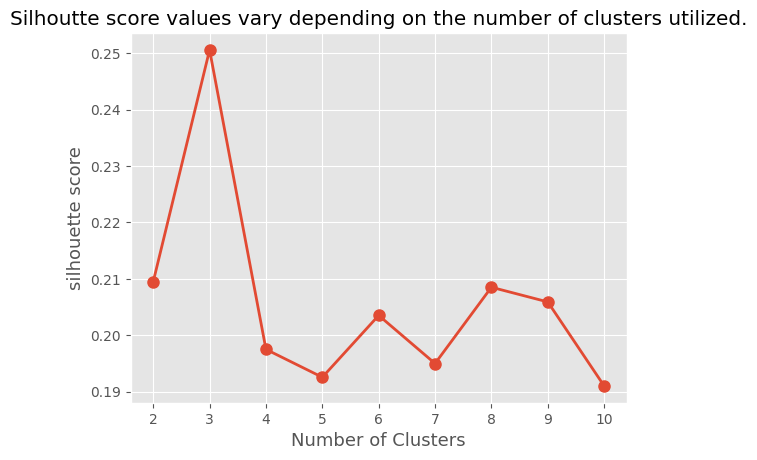

In [ ]:
plt.plot(range(2,11),sh_list, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("silhouette score", size=13)
plt.title("Silhoutte score values vary depending on the number of clusters utilized.")
plt.show()
# di stage ini kita menemukan k=2 dengan score tertinggi

In [ ]:
sh_list = []

for num_clusters in range(2, 11):
    kmedoids = KMedoids(n_clusters=num_clusters)
    cluster_labels = kmedoids.fit_predict(X_new)
    score = silhouette_score(X_new, cluster_labels)
    sh_list.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(num_clusters, score))

For n_clusters = 2, silhouette score is 0.1945165537378692
For n_clusters = 3, silhouette score is 0.16024040458444103
For n_clusters = 4, silhouette score is 0.13738603460433335
For n_clusters = 5, silhouette score is 0.14859330798827058
For n_clusters = 6, silhouette score is 0.07497117420304265
For n_clusters = 7, silhouette score is 0.051193591100429474
For n_clusters = 8, silhouette score is 0.03912406632314492
For n_clusters = 9, silhouette score is 0.08491760468793152
For n_clusters = 10, silhouette score is 0.03469231089500277


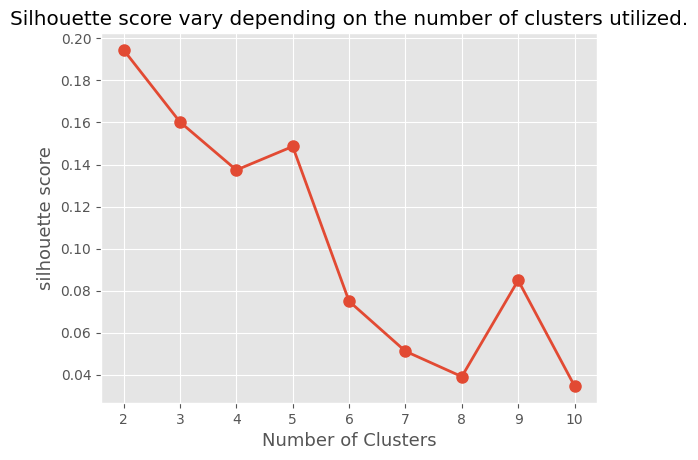

In [ ]:
# visualisasi silhoutte

plt.plot(range(2,11),sh_list, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("silhouette score", size=13)
plt.title("Silhouette score vary depending on the number of clusters utilized.")
plt.show()

In [ ]:
# algoritma kmeans menggunakan nilai silhoutte

k_means = KMeans(n_clusters = 2, random_state = 42)
k_means.fit(X_new)
labels = k_means.labels_
df_new['cluster_labels'] = labels
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_labels
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [ ]:
# cek centroids

centroids = k_means.cluster_centers_
centroids

array([[ 0.28073957,  0.43247256,  1.10795859,  0.89576982,  0.97358346,
        -0.10307996,  1.1156293 ,  1.29514356,  0.87789229, -0.26387424,
        -0.14839813,  1.26760651,  0.74056992,  0.64489838,  0.15037657,
         0.44987573,  0.27971163],
       [-0.07339984, -0.1130707 , -0.28967769, -0.23420057, -0.25454508,
         0.02695043, -0.29168321, -0.33861752, -0.22952646,  0.06899037,
         0.03879895, -0.33141791, -0.19362328, -0.16860979, -0.03931621,
        -0.11762079, -0.07313109]])

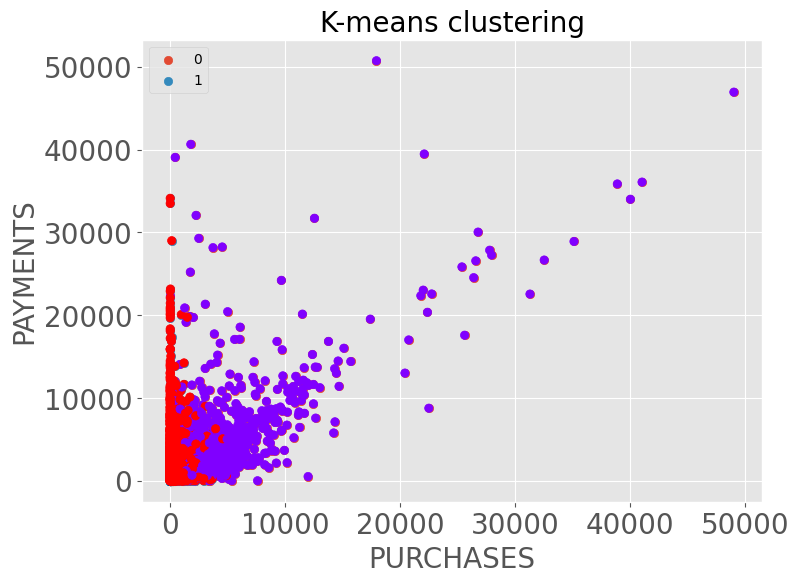

In [ ]:
# visualisasi

x1 = df_new['PURCHASES']
x2 = df_new['PAYMENTS']

plt.figure(figsize=(8,6))
u_labels = np.unique(labels)
for i in u_labels:
    plt.scatter(x1[df_new['cluster_labels'] == i] , x2[df_new['cluster_labels'] == i] , label = i)

plt.scatter(x1,x2, c=k_means.labels_, cmap='rainbow')
plt.xlabel(x1.name, fontsize=20)
plt.ylabel(x2.name, fontsize=20)
plt.title('K-means clustering',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()
plt.show()

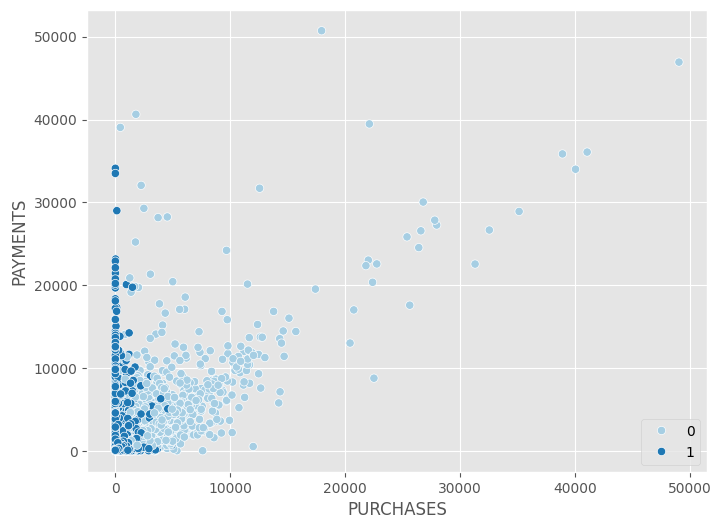

In [ ]:
# visualisasi seaborn

plt.figure(figsize=(8,6))
x_val = 'PURCHASES'
y_val = 'PAYMENTS'
sns.scatterplot(x=x_val, y=y_val, hue='cluster_labels', data=df_new, palette='Paired')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# visualisasi plotly

x_val = 'PURCHASES'
y_val = 'PAYMENTS'
z_val = 'BALANCE'
fig = px.scatter_3d(df_new, x=x_val, y=y_val, z=z_val, color='cluster_labels', labels='cluster_labels')
fig.show()

In [ ]:
# algoritma kmedoids menggunakan elbow

k_medoids = KMedoids(n_clusters = 4, random_state = 42)
k_medoids.fit(X_new)
labels = k_medoids.labels_
df_new['cluster_labels'] = labels
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_labels
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,3
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


In [ ]:
# cek centroids

centroids = k_medoids.cluster_centers_
centroids

array([[-0.73017008, -1.78447531, -0.15174467,  0.01660604, -0.3893315 ,
        -0.46678555, -0.39122513, -0.39931927, -0.49762862, -0.67534886,
        -0.47606982, -0.39063931, -0.20456068, -0.35069111, -0.32756103,
         0.50015018,  0.36067954],
       [-0.65121444,  0.51808382,  0.24224266,  0.03901242,  0.50039651,
        -0.46678555,  1.06221062,  0.15936716,  1.38951716, -0.67534886,
        -0.47606982,  0.37375564, -0.27327139,  0.0131038 , -0.2796588 ,
         0.04428414,  0.36067954],
       [-0.04321221,  0.51808382, -0.41993839, -0.29307072, -0.45457623,
        -0.44947139, -1.01412545, -0.39931927, -0.91699519, -0.25891333,
        -0.18299798, -0.51133325, -0.41069279, -0.47801089, -0.17593333,
        -0.52555097,  0.36067954],
       [ 1.16410803,  0.51808382, -0.40096824, -0.32982224, -0.3423    ,
         0.80421891, -0.18359002, -0.39931927, -0.2879466 ,  1.8232743 ,
         0.69621752, -0.350408  ,  0.41383563, -0.14385479,  0.17482124,
        -0.52555097

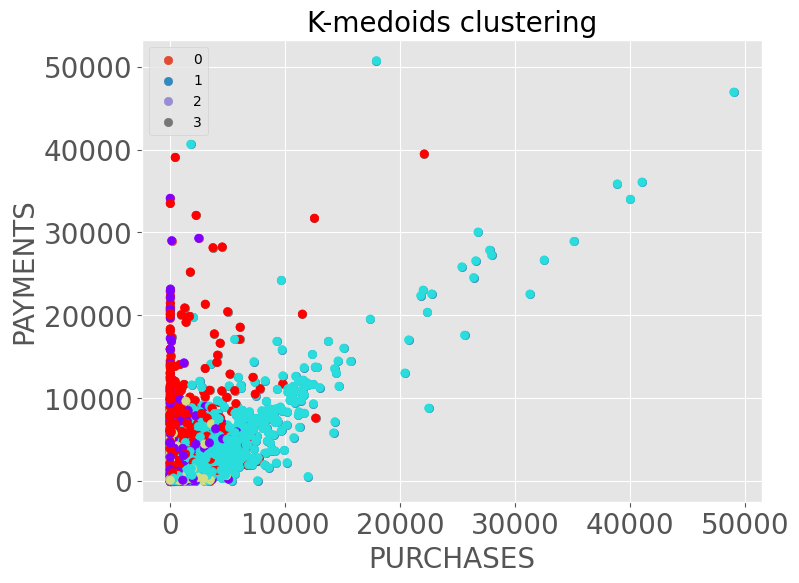

In [ ]:
# visualisasi

x1 = df_new['PURCHASES']
x2 = df_new['PAYMENTS']

plt.figure(figsize=(8,6))
u_labels = np.unique(labels)
for i in u_labels:
    plt.scatter(x1[df_new['cluster_labels'] == i] , x2[df_new['cluster_labels'] == i] , label = i)

plt.scatter(x1,x2, c=k_medoids.labels_, cmap='rainbow')
plt.xlabel(x1.name,  fontsize=20)
plt.ylabel(x2.name,  fontsize=20)
plt.title('K-medoids clustering',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()
plt.show()

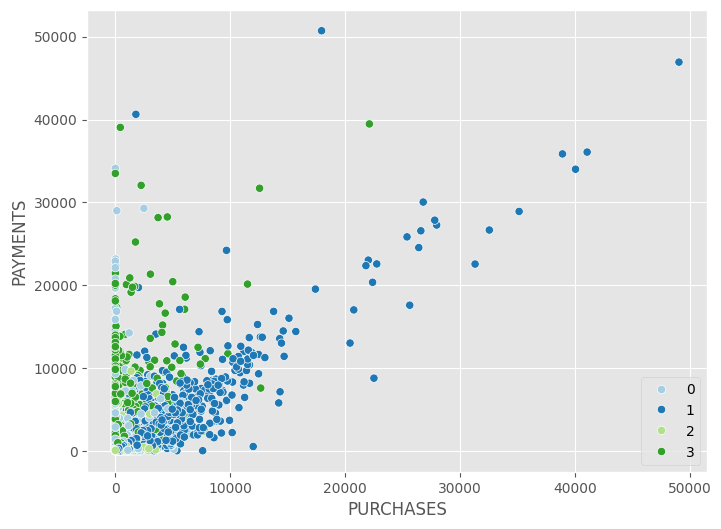

In [ ]:

# visualisas seaborn

plt.figure(figsize=(8,6))
x_val = 'PURCHASES'
y_val = 'PAYMENTS'

sns.scatterplot(x=x_val, y=y_val, hue='cluster_labels', data=df_new, palette='Paired')
plt.legend(loc='lower right')
plt.show()

# Tugas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from kneed import KneeLocator, DataGenerator
from sklearn.metrics import silhouette_samples, silhouette_score
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [ ]:
# load dataset
df = pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/Air_Traffic_Passenger_Statistics_20260921.csv')
df.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,"31,432",2026/08/20 01:00:20 PM,2026/09/20 03:14:35 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,"31,353",2026/08/20 01:00:20 PM,2026/09/20 03:14:35 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,"2,518",2026/08/20 01:00:20 PM,2026/09/20 03:14:35 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,"1,324",2026/08/20 01:00:20 PM,2026/09/20 03:14:35 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,"1,198",2026/08/20 01:00:20 PM,2026/09/20 03:14:35 PM


In [ ]:
df.shape

(40626, 15)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Activity Period,40626.0,201349.446611,795.810775,199907.0,200702.0,201406.0,202010.0,202607.0


In [ ]:
df_task = df.copy()
display(df_task.isnull().sum())
display(df_task.dtypes)

,0
Activity Period,0
Activity Period Start Date,0
Operating Airline,0
Operating Airline IATA Code,316
Published Airline,0
Published Airline IATA Code,316
GEO Summary,0
GEO Region,0
Activity Type Code,0
Price Category Code,0


,0
Activity Period,int64
Activity Period Start Date,object
Operating Airline,object
Operating Airline IATA Code,object
Published Airline,object
Published Airline IATA Code,object
GEO Summary,object
GEO Region,object
Activity Type Code,object
Price Category Code,object


In [ ]:
df_task['Operating Airline IATA Code'] = df_task['Operating Airline IATA Code'].fillna('Unknown')
df_task['Published Airline IATA Code'] = df_task['Published Airline IATA Code'].fillna('Unknown')

passenger_col = 'Passenger Count'
if df_task[passenger_col].dtype == 'object':
    df_task[passenger_col] = df_task[passenger_col].str.replace(',', '').astype(float)

categorical_cols = df_task.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_task[col] = le.fit_transform(df_task[col].astype(str))

display(df_task.head())

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,0,1,95,1,88,0,8,0,0,2,1,31432.0,0,0
1,199907,0,1,95,1,88,0,8,1,0,2,1,31353.0,0,0
2,199907,0,1,95,1,88,0,8,2,0,2,1,2518.0,0,0
3,199907,0,3,98,3,91,1,4,0,1,3,3,1324.0,0,0
4,199907,0,3,98,3,91,1,4,1,1,3,3,1198.0,0,0


In [ ]:
X_task = df_task.astype(float).values
scaler_task = StandardScaler()
X_task_scaled = scaler_task.fit_transform(X_task)
print(X_task_scaled.shape)

(40626, 15)


In [ ]:
inertia_kmeans_task = []
for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_model.fit(X_task_scaled)
    inertia_kmeans_task.append(kmeans_model.inertia_)
    print(f"n_clusters = {num_clusters}, inertia = {kmeans_model.inertia_}")

n_clusters = 1, inertia = 568763.9999999955
n_clusters = 2, inertia = 441829.19987647264
n_clusters = 3, inertia = 388934.5832954555
n_clusters = 4, inertia = 340917.7001807295
n_clusters = 5, inertia = 297728.4162749625
n_clusters = 6, inertia = 274858.18394036265
n_clusters = 7, inertia = 271777.50958503823
n_clusters = 8, inertia = 245104.3025020097
n_clusters = 9, inertia = 230175.94016647508
n_clusters = 10, inertia = 217483.84419455996


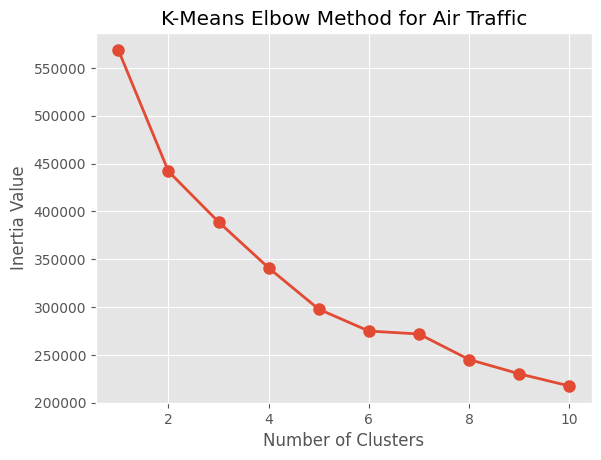

In [ ]:
plt.plot(range(1, 11), inertia_kmeans_task, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Value")
plt.title("K-Means Elbow Method for Air Traffic")
plt.show()

Optimal K (Elbow): 5


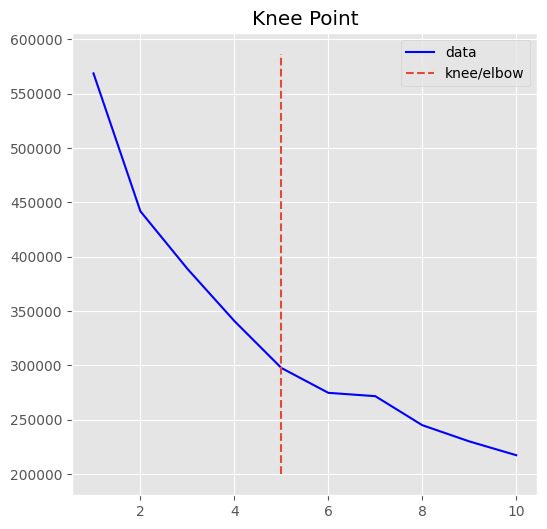

In [ ]:
kneedle_task = KneeLocator(range(1, 11), inertia_kmeans_task, S=1.0, curve='convex', direction='decreasing')
print("Optimal K (Elbow):", kneedle_task.knee)
kneedle_task.plot_knee()
plt.show()

In [ ]:
sh_kmeans_task = []
for num_clusters in range(2, 6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_task_scaled)
    score = silhouette_score(X_task_scaled, cluster_labels)
    sh_kmeans_task.append(score)
    print(f"K-Means n_clusters = {num_clusters}, silhouette score = {score}")

K-Means n_clusters = 2, silhouette score = 0.22124789125768346
K-Means n_clusters = 3, silhouette score = 0.2072165538026131
K-Means n_clusters = 4, silhouette score = 0.2290983790439252
K-Means n_clusters = 5, silhouette score = 0.24161915823158397


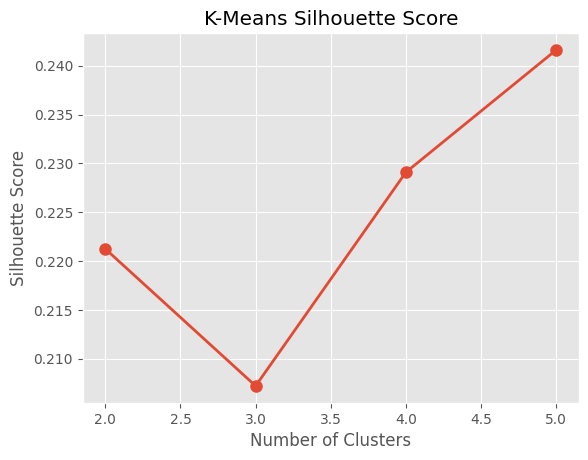

In [ ]:
plt.plot(range(2, 6), sh_kmeans_task, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.show()

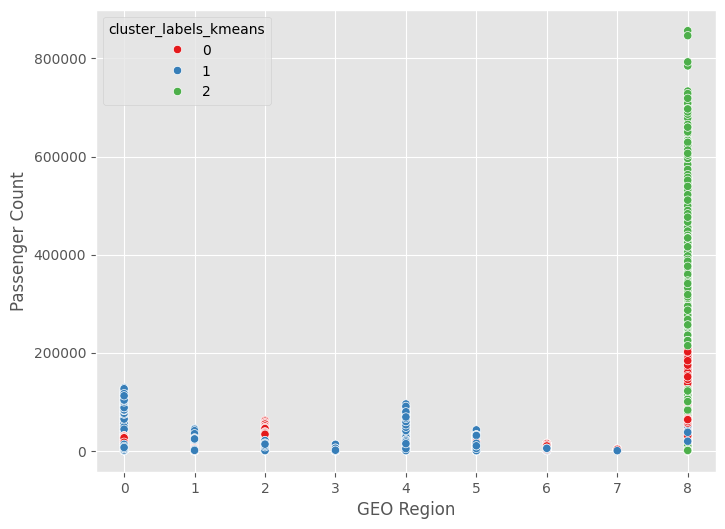

In [ ]:
k_means_optimal = KMeans(n_clusters=3, random_state=42)
df_task['cluster_labels_kmeans'] = k_means_optimal.fit_predict(X_task_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x='GEO Region', y='Passenger Count', hue='cluster_labels_kmeans', data=df_task, palette='Set1')
plt.show()